In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("telecom-customer-churn-dataset.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].isnull().sum())

11


In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [9]:
col = list(df.columns)
cat_cols = []
num_cols = []
for i in col:
    if len(df[i].unique()) > 6:
        num_cols.append(i)
    else:
        cat_cols.append(i)
num_cols.remove('customerID')
print('Categorical Features\n', cat_cols)
print('Numerical Features\n', num_cols)

Categorical Features
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Numerical Features
 ['tenure', 'MonthlyCharges', 'TotalCharges']


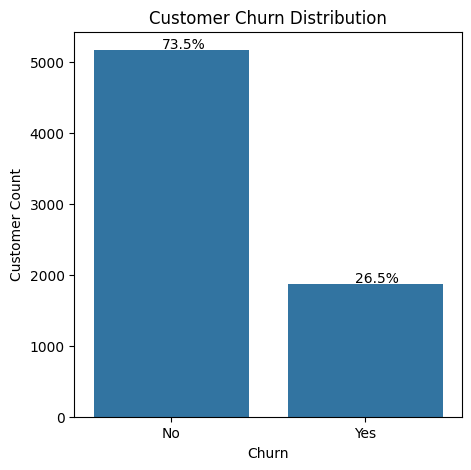

In [10]:
plt.figure(figsize=(5, 5))
ax = sns.countplot(x='Churn', data=df)

for p in ax.patches:
    pct = 100*p.get_height()/len(df)
    ax.annotate(f'{pct:.1f}%', (p.get_x()+0.35, p.get_height()+20))

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Customer Count')
plt.show()

In [11]:
customer_info = ['gender','SeniorCitizen','Partner','Dependents']

service_info = ['PhoneService','MultipleLines','InternetService',
                'OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']

account_info = ['Contract','PaperlessBilling','PaymentMethod']

def churn_plot(cols,rows,cols_subplot):
    plt.figure(figsize=(18,12))

    for i,col in enumerate(cols):
        plt.subplot(rows,cols_subplot,i+1)

        ax = sns.countplot(x=col,data=df,hue='Churn',edgecolor='black')

        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}',
                        (p.get_x()+p.get_width()/2,p.get_height()),
                        ha='center',fontsize=9)

        plt.title(f'{col} vs Churn')

    plt.tight_layout()
    plt.show()

**Customer Information** (SeniorCitizen, Partner, Dependents)

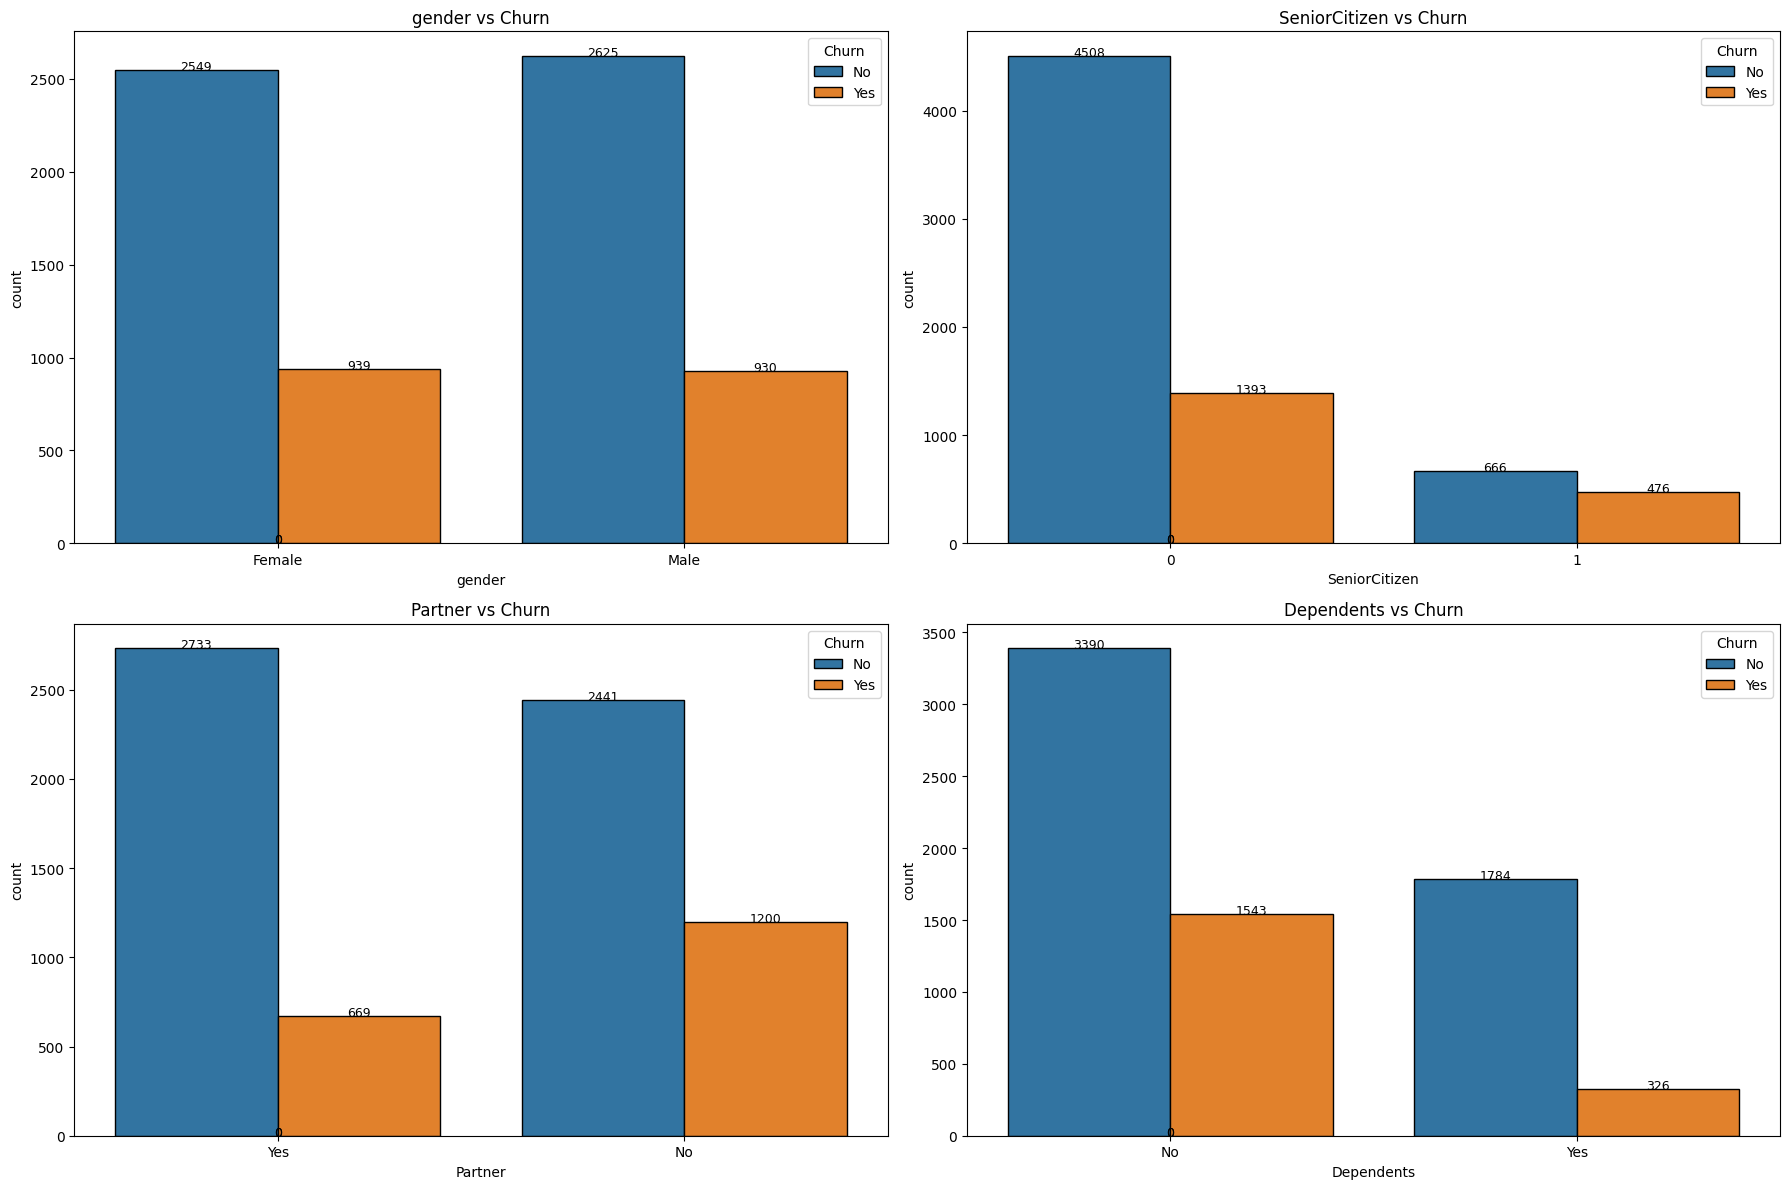

In [12]:
churn_plot(customer_info,2,2)

**Service Information**  
(PhoneService, MultipleLines, InternetService,   
OnlineSecurity, OnlineBackup, DeviceProtection,  
TechSupport, StreamingTV, StreamingMovies, )

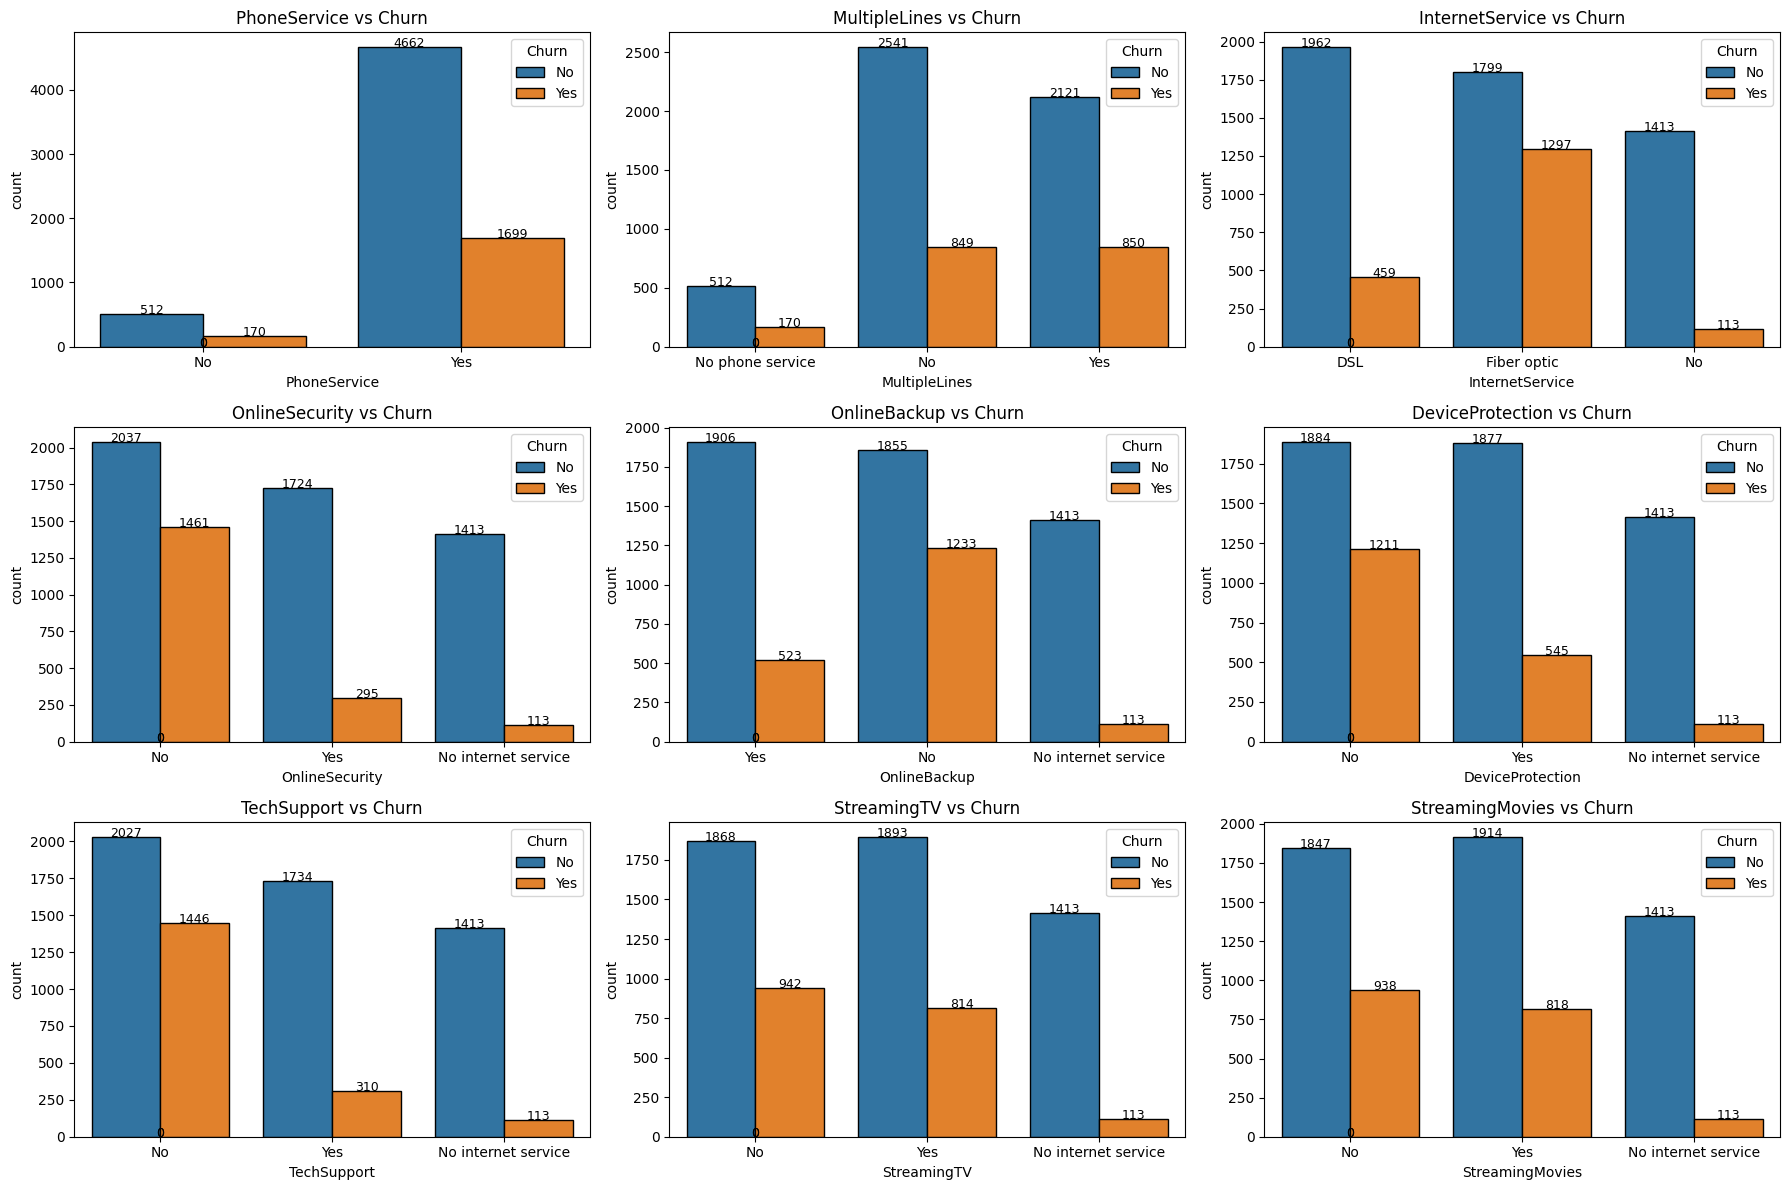

In [13]:
churn_plot(service_info,3,3)

**Account Information** (Contract, Paperless Billing, Payment Method)

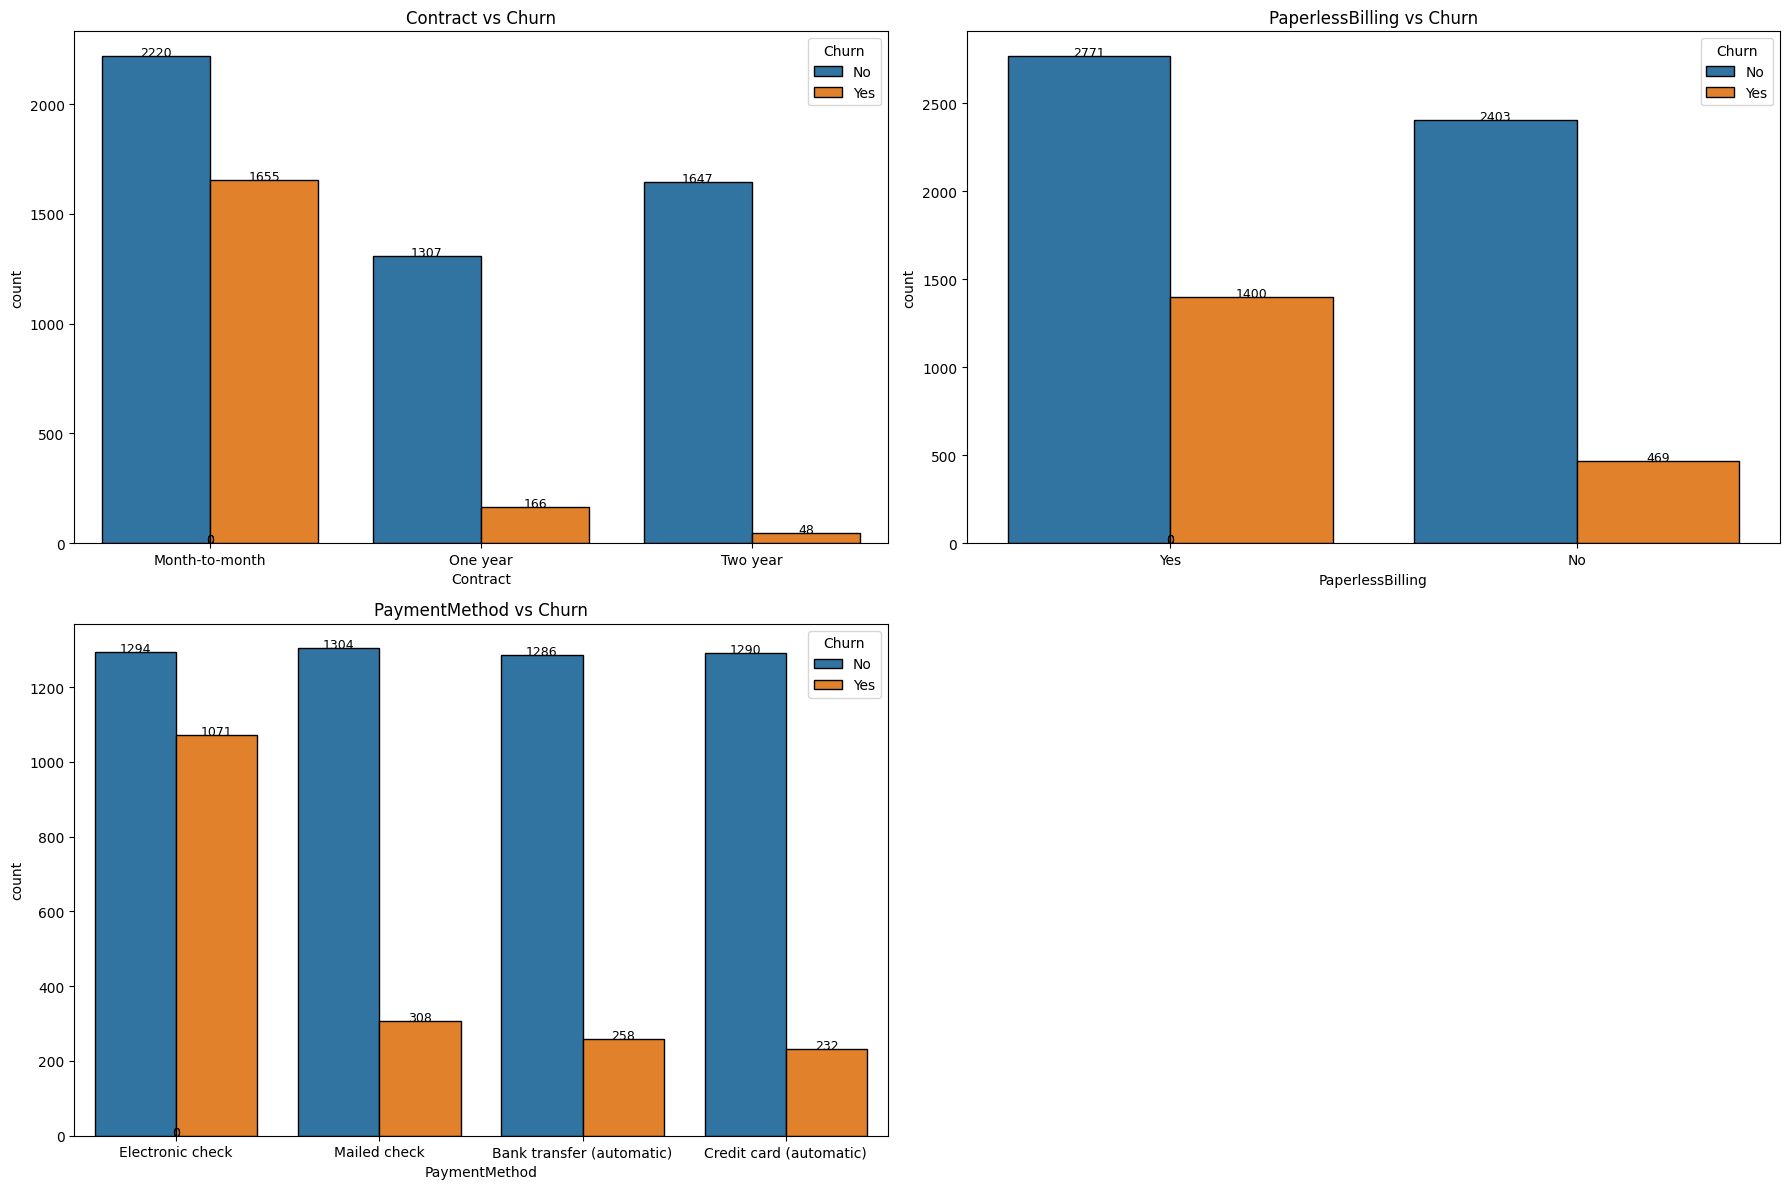

In [14]:
churn_plot(account_info,2,2)

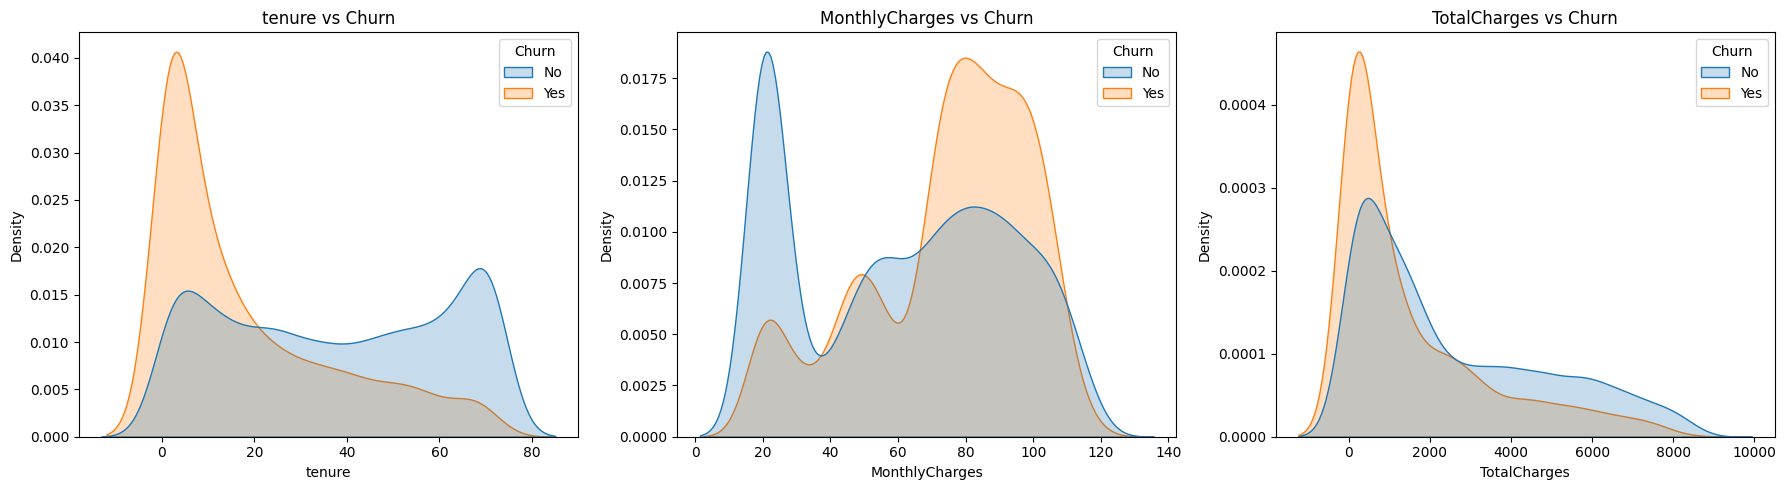

In [15]:
fig, ax = plt.subplots(1,3,figsize=(18,5))

for i,col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, ax=ax[i])
    ax[i].set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

#### **Future Engineering**

In [16]:
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()

for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

df_corr.drop(columns=['customerID'], inplace=True)

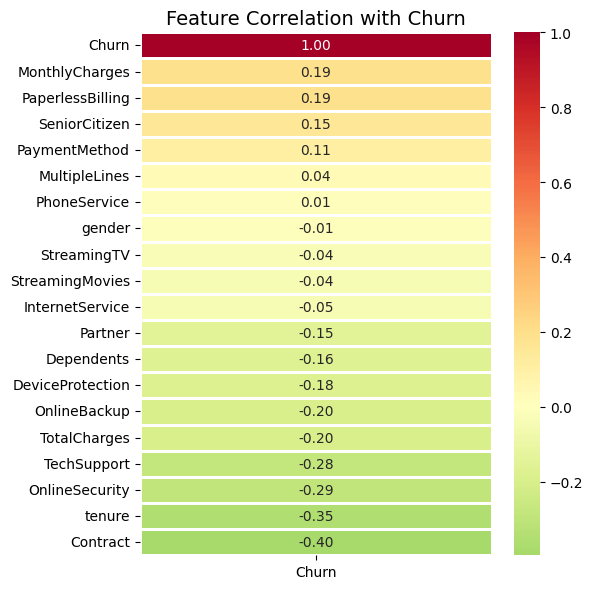

In [17]:
corr = df_corr.corr()[['Churn']].sort_values(by='Churn', ascending=False)

plt.figure(figsize=(6,6))
sns.heatmap(corr, annot=True, cmap='RdYlGn_r',
            center=0, fmt='.2f', linewidths=1, cbar=True)
plt.title('Feature Correlation with Churn', fontsize=14)
plt.tight_layout()
plt.show()

Chi Square Test for Categorical Columns

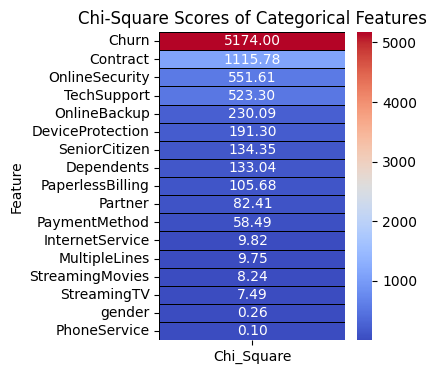

In [18]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2

cat_df = df[cat_cols].copy()

for col in cat_df.columns:
    cat_df[col] = LabelEncoder().fit_transform(cat_df[col])

target = LabelEncoder().fit_transform(df['Churn'])

chi_selector = SelectKBest(chi2, k='all')
chi_selector.fit(cat_df, target)

featureScores = pd.DataFrame({
    'Feature': cat_df.columns,
    'Chi_Square': chi_selector.scores_
}).sort_values('Chi_Square', ascending=False)

plt.figure(figsize=(3,4))

sns.heatmap(featureScores.set_index('Feature'),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5,
            linecolor='black')

plt.title('Chi-Square Scores of Categorical Features')
plt.show()

PhoneService, gender, StreamingTV, StreamingMovies, MultipleLines and InternetService display a very low relation with Churn.

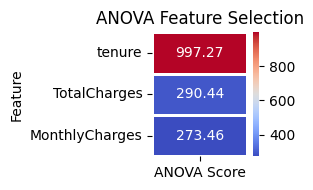

In [19]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder

X = df[num_cols]

y = LabelEncoder().fit_transform(df['Churn'])

anova = SelectKBest(score_func=f_classif, k='all')
anova.fit(X, y)

anova_scores = pd.DataFrame({
    'Feature': num_cols,
    'ANOVA Score': anova.scores_
}).sort_values('ANOVA Score', ascending=False)
plt.figure(figsize=(3,2))

sns.heatmap(anova_scores.set_index('Feature'),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=1)

plt.title('ANOVA Feature Selection')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

df['Churn'] = df['Churn'].map({'No':0,'Yes':1})

le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
df.drop('customerID', axis=1, inplace=True)
df.drop(columns = ['PhoneService', 'gender','StreamingTV',
                   'StreamingMovies','MultipleLines','InternetService'], axis=1, inplace = True)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,0,2,0,0,0,1,2,29.85,29.85,0
1,0,0,0,34,2,0,2,0,1,0,3,56.95,1889.50,0
2,0,0,0,2,2,2,0,0,0,1,3,53.85,108.15,1
3,0,0,0,45,2,0,2,2,1,0,0,42.30,1840.75,0
4,0,0,0,2,0,0,0,0,0,1,2,70.70,151.65,1


In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.000,0.000,0.00,1.00
Partner,7043.0,0.483033,0.499748,0.00,0.000,0.000,1.00,1.00
Dependents,7043.0,0.299588,0.458110,0.00,0.000,0.000,1.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
OnlineSecurity,7043.0,0.790004,0.859848,0.00,0.000,1.000,2.00,2.00
OnlineBackup,7043.0,0.906432,0.880162,0.00,0.000,1.000,2.00,2.00
DeviceProtection,7043.0,0.904444,0.879949,0.00,0.000,1.000,2.00,2.00
TechSupport,7043.0,0.797104,0.861551,0.00,0.000,1.000,2.00,2.00
Contract,7043.0,0.690473,0.833755,0.00,0.000,0.000,1.00,2.00
PaperlessBilling,7043.0,0.592219,0.491457,0.00,0.000,1.000,1.00,1.00


In [22]:
df.to_csv('telecom_churn_cleaned.csv', index=False)